## 2) Datenanalyse und Vorbereitung
2.1 Laden des CIFAR-10 Datensatzes

In [ ]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from pathlib import Path
from sklearn.model_selection import train_test_split

def _unpickle(file_path: Path):
    with open(file_path, "rb") as f:
        return pickle.load(f, encoding="bytes")

def load_cifar10_local(datasets_dir: Path):
    datasets_dir = Path(datasets_dir)

    required = [datasets_dir / f"data_batch_{i}" for i in range(1, 6)] + [
        datasets_dir / "test_batch",
        datasets_dir / "batches.meta",
    ]
    missing = [p for p in required if not p.exists()]
    if missing:
        raise FileNotFoundError(
            "CIFAR-10 Dateien nicht gefunden. Fehlend:\n" + "\n".join(str(p) for p in missing)
            + "\n\nTipp: Öffne den Ordner `1_CNN` als Projekt/Workspace, damit `Path.cwd()` auf `1_CNN` zeigt."
        )

    meta = _unpickle(datasets_dir / "batches.meta")
    label_names = meta.get(b"label_names")
    class_names = [x.decode("utf-8") for x in label_names]

    xs, ys = [], []
    for i in range(1, 6):
        batch = _unpickle(datasets_dir / f"data_batch_{i}")
        xs.append(batch[b"data"])
        ys.extend(batch[b"labels"])

    x_train = np.vstack(xs).reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    y_train = np.array(ys, dtype=np.int64)

    test = _unpickle(datasets_dir / "test_batch")
    x_test = test[b"data"].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    y_test = np.array(test[b"labels"], dtype=np.int64)

    return (x_train, y_train), (x_test, y_test), class_names

datasets_dir = Path.cwd() / "CNN_Datensätze"

(x_train_full, y_train_full), (x_test, y_test), class_names = load_cifar10_local(datasets_dir)

print("Lokal geladen!")
print("x_train_full:", x_train_full.shape, "y_train_full:", y_train_full.shape)
print("x_test:", x_test.shape, "y_test:", y_test.shape)
print("Klassen:", class_names)

Lokal geladen!
x_train_full: (50000, 32, 32, 3) y_train_full: (50000,)
x_test: (10000, 32, 32, 3) y_test: (10000,)
Klassen: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


C:\Users\cosen\AppData\Local\Temp\ipykernel_18292\758057616.py:11: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  return pickle.load(f, encoding="bytes")


2.2 Durchführung einer ersten Exploration der Daten

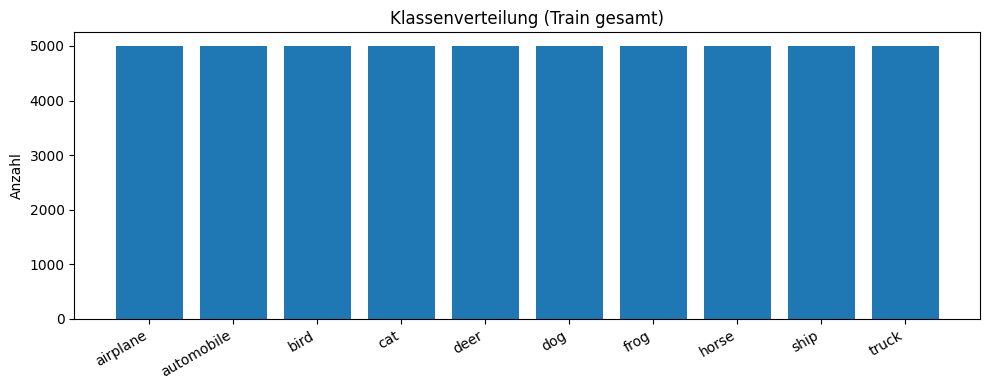

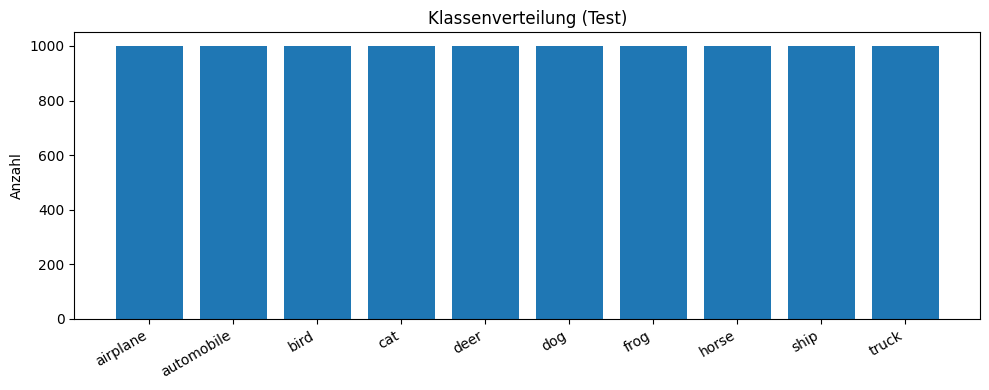

In [ ]:
counts_train = np.bincount(y_train_full, minlength=10)
plt.figure(figsize=(10,4))
plt.bar(class_names, counts_train)
plt.title("Klassenverteilung (Train gesamt)")
plt.ylabel("Anzahl")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

counts_test = np.bincount(y_test, minlength=10)
plt.figure(figsize=(10,4))
plt.bar(class_names, counts_test)
plt.title("Klassenverteilung (Test)")
plt.ylabel("Anzahl")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

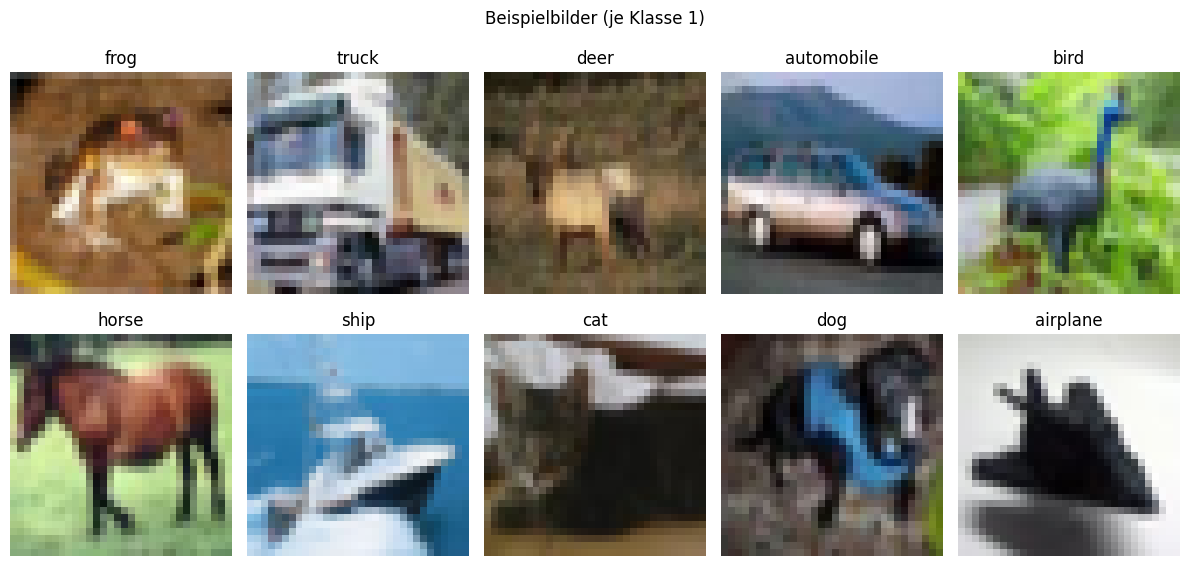

In [ ]:
plt.figure(figsize=(12,6))
shown = {i: False for i in range(10)}
idx = 0
pos = 1
while pos <= 10 and idx < len(x_train_full):
    label = int(y_train_full[idx])
    if not shown[label]:
        plt.subplot(2,5,pos)
        plt.imshow(x_train_full[idx])
        plt.title(class_names[label])
        plt.axis("off")
        shown[label] = True
        pos += 1
    idx += 1
plt.suptitle("Beispielbilder (je Klasse 1)")
plt.tight_layout()
plt.show()

2.3 Daten aufbereiten und Normieren

In [11]:
x_train_full = x_train_full.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Min/Max train:", x_train_full.min(), x_train_full.max())
print("Min/Max test:", x_test.min(), x_test.max())

Min/Max train: 0.0 1.0
Min/Max test: 0.0 1.0


2.4 Datenaufteilung in Trainings-, Validierungs- und Testdatensatz

Train: (40000, 32, 32, 3) (40000,)
Val:   (10000, 32, 32, 3) (10000,)
Test:  (10000, 32, 32, 3) (10000,)


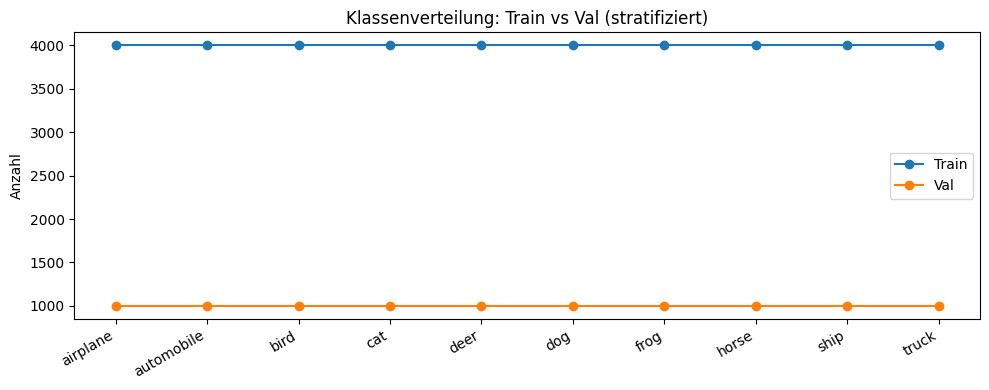

In [12]:
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full
)

print("Train:", x_train.shape, y_train.shape)
print("Val:  ", x_val.shape, y_val.shape)
print("Test: ", x_test.shape, y_test.shape)

train_counts = np.bincount(y_train, minlength=10)
val_counts = np.bincount(y_val, minlength=10)

plt.figure(figsize=(10,4))
plt.plot(class_names, train_counts, marker="o", label="Train")
plt.plot(class_names, val_counts, marker="o", label="Val")
plt.title("Klassenverteilung: Train vs Val (stratifiziert)")
plt.ylabel("Anzahl")
plt.xticks(rotation=30, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

---
## 3) Modellaufbau und Training 
3.1 Erstellung und Training eines CNN

In [ ]:
tf.random.set_seed(42)
np.random.seed(42)

model = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),

    layers.Conv2D(32, (3,3), padding="same", activation="relu"),
    layers.Conv2D(32, (3,3), padding="same", activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3,3), padding="same", activation="relu"),
    layers.Conv2D(64, (3,3), padding="same", activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(10, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,116,970 (4.26 MB)

 Trainable params: 1,116,970 (4.26 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [15]:
history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=10,
    batch_size=64,
    verbose=1
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 36s 55ms/step - accuracy: 0.3862 - loss: 1.6659 - val_accuracy: 0.5741 - val_loss: 1.1915
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 33s 53ms/step - accuracy: 0.5707 - loss: 1.2041 - val_accuracy: 0.6455 - val_loss: 0.9859
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 33s 53ms/step - accuracy: 0.6326 - loss: 1.0307 - val_accuracy: 0.6864 - val_loss: 0.8724
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 33s 53ms/step - accuracy: 0.6735 - loss: 0.9264 - val_accuracy: 0.7157 - val_loss: 0.8025
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 34s 55ms/step - accuracy: 0.6997 - loss: 0.8526 - val_accuracy: 0.7314 - val_loss: 0.7667
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 33s 53ms/step - accuracy: 0.7209 - loss: 0.7929 - val_accuracy: 0.7460 - val_loss: 0.7271
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 33s 53ms/step - accuracy: 0.7338 - loss: 0.7522 - val_accuracy: 0.7446 - val_loss: 0.7444
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 33s 53ms/step - accuracy: 0.7501 - loss: 0.7050 - 

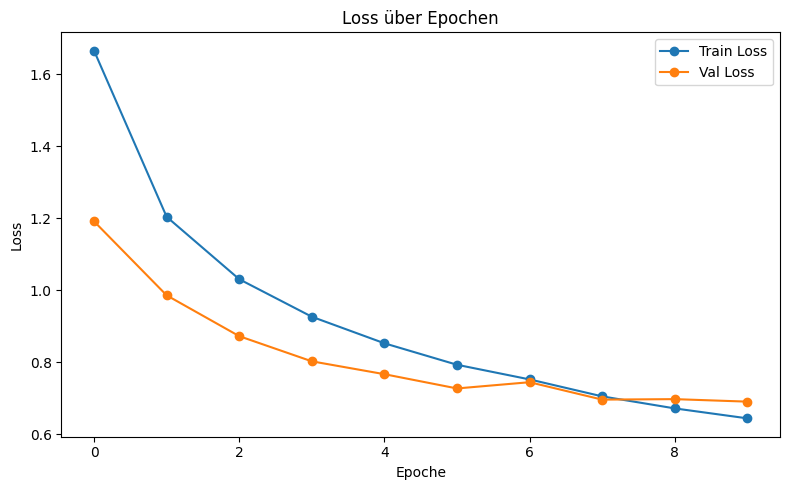

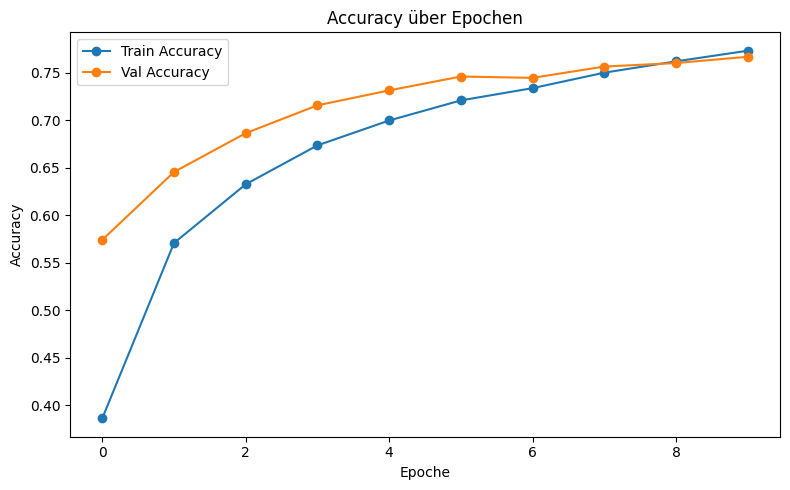

In [16]:
hist = history.history

plt.figure(figsize=(8,5))
plt.plot(hist["loss"], marker="o", label="Train Loss")
plt.plot(hist["val_loss"], marker="o", label="Val Loss")
plt.title("Loss über Epochen")
plt.xlabel("Epoche")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(hist["accuracy"], marker="o", label="Train Accuracy")
plt.plot(hist["val_accuracy"], marker="o", label="Val Accuracy")
plt.title("Accuracy über Epochen")
plt.xlabel("Epoche")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

## Evaluation auf dem Testdatensatz

In [17]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


Test Loss: 0.7034
Test Accuracy: 0.7607


## Optional: Beispielvorhersagen

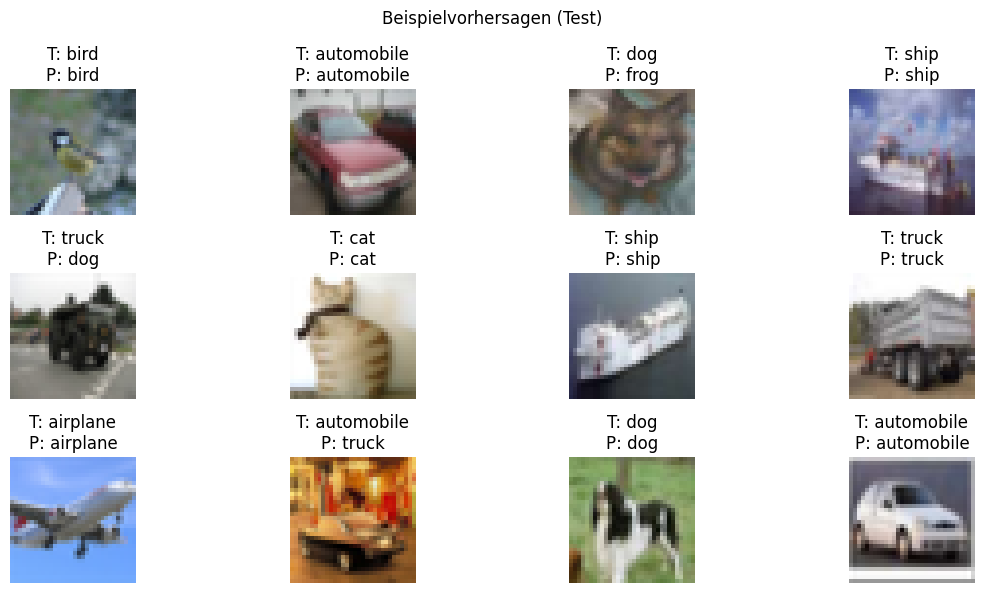

In [18]:
num_show = 12
idxs = np.random.choice(len(x_test), size=num_show, replace=False)

pred = model.predict(x_test[idxs], verbose=0)
pred_labels = np.argmax(pred, axis=1)

plt.figure(figsize=(12,6))
for i, idx in enumerate(idxs, start=1):
    plt.subplot(3,4,i)
    plt.imshow(x_test[idx])
    true_label = class_names[int(y_test[idx])]
    pred_label = class_names[int(pred_labels[i-1])]
    plt.title(f"T: {true_label}\nP: {pred_label}")
    plt.axis("off")

plt.suptitle("Beispielvorhersagen (Test)")
plt.tight_layout()
plt.show()
